<a href="https://colab.research.google.com/github/asfahanahmad/House-Price-Segmentation-using-K-Means-Hierarchical-Clustering/blob/main/Segmentation_AmesHousing_KMeans_Hierarchical_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentation (Clustering) — AmesHousing (Colab)
**Course:** Predictive Analytics with Python (MBA)  
**Session Topic:** Segmentation using **K‑Means** and **Hierarchical Clustering**  
**Dataset:** `AmesHousing.csv` (manual upload)

## Tools used
- **Pandas**: load + cleaning + profiling tables  
- **NumPy**: numeric operations  
- **Matplotlib** (+ optional Seaborn): visuals  
- **scikit‑learn**: StandardScaler, KMeans, AgglomerativeClustering, PCA, silhouette  
- **SciPy**: dendrogram/linkage + statistical tests (ANOVA / Kruskal)

## Learning outcomes
1. Prepare data for clustering (missing values, scaling)
2. Build segments using K‑Means and Hierarchical clustering
3. Choose number of clusters (Elbow + Silhouette)
4. Profile clusters and interpret them as business “personas”
5. Validate differences between clusters using statistical tests


In [ ]:
# Code Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # optional styling

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120


## 1) Upload & Load the dataset (manual upload)

In [ ]:
# Code Cell 2: Upload AmesHousing.csv
uploaded = files.upload()  # choose AmesHousing.csv
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

df = pd.read_csv(filename)
print("Raw shape:", df.shape)
df.head()


Saving AmesHousing.csv to AmesHousing.csv
Uploaded file: AmesHousing.csv
Raw shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2) Pick features for segmentation
We use interpretable numeric features to create clusters.

**We do NOT use SalePrice to create clusters** (otherwise clusters become “price buckets”).  
We use SalePrice only to evaluate how segments differ.


In [ ]:
# Code Cell 3: Create clustering dataset
cluster_features = ["Gr Liv Area", "Overall Qual", "Total Bsmt SF", "Garage Area", "Year Built", "Lot Area"]
target_for_evaluation = "SalePrice"

# df_seg = df[cluster_features + [target_for_evaluation]].copy()

id_col = "PID"   # keep identifier for labels
df_seg = df[[id_col] + cluster_features + [target_for_evaluation]].copy()
print("Missing values (top):")
print(df_seg.isna().sum().sort_values(ascending=False).head(10))

df_seg = df_seg.dropna()
print("\nRows after dropping NA:", df_seg.shape[0])

df_seg.head()


Missing values (top):
Total Bsmt SF    1
Garage Area      1
Gr Liv Area      0
PID              0
Overall Qual     0
Year Built       0
Lot Area         0
SalePrice        0
dtype: int64

Rows after dropping NA: 2928


,PID,Gr Liv Area,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Lot Area,SalePrice
0,526301100,1656,6,1080.0,528.0,1960,31770,215000
1,526350040,896,5,882.0,730.0,1961,11622,105000
2,526351010,1329,6,1329.0,312.0,1958,14267,172000
3,526353030,2110,7,2110.0,522.0,1968,11160,244000
4,527105010,1629,5,928.0,482.0,1997,13830,189900


## 3) Standardize features (important)
Clustering is distance-based. Without scaling, large-number columns dominate.


In [ ]:
# Code Cell 4: Standardize
X = df_seg[cluster_features].values
y_price = df_seg[target_for_evaluation].values  # evaluation only

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape


(2928, 6)

## 4) Choose number of clusters (Elbow + Silhouette)

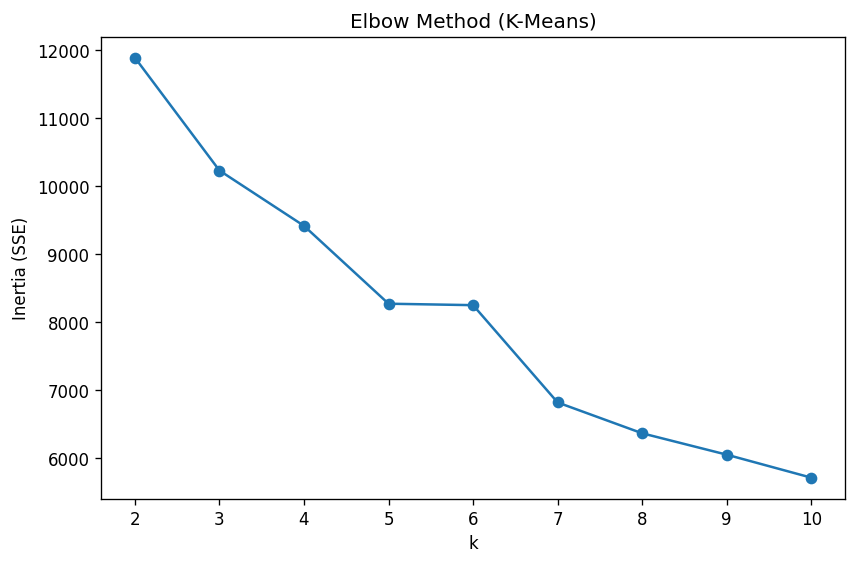

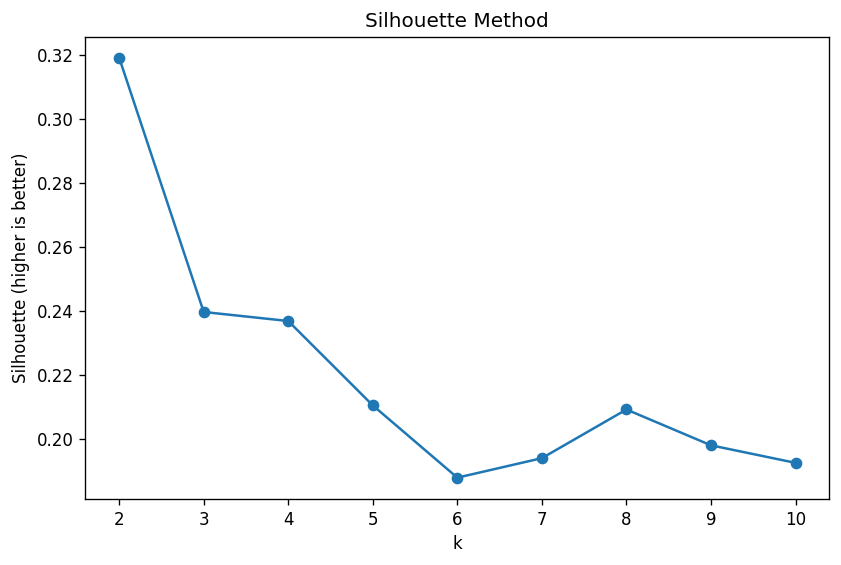

,k,inertia,silhouette
0,2,11893.433916,0.319086
1,3,10233.080677,0.239567
2,4,9418.933596,0.236743
3,5,8273.391306,0.210361
4,6,8252.132100,0.187761
5,7,6820.583733,0.193861
6,8,6366.961055,0.209077
7,9,6052.283806,0.197877
8,10,5714.015677,0.192394


In [ ]:
# Code Cell 5: Elbow + Silhouette sweep
Ks = range(2, 11)
inertias, silhouettes = [], []

rng = np.random.RandomState(42)
if X_scaled.shape[0] > 2000:
    idx = rng.choice(X_scaled.shape[0], 2000, replace=False)
    X_sil = X_scaled[idx]
else:
    idx = None
    X_sil = X_scaled

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if idx is None:
        silhouettes.append(silhouette_score(X_scaled, labels))
    else:
        silhouettes.append(silhouette_score(X_sil, labels[idx]))

plt.figure()
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means)")
plt.show()

plt.figure()
plt.plot(list(Ks), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette (higher is better)")
plt.title("Silhouette Method")
plt.show()

pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": silhouettes})


## 5) Fit final K-Means model
Change `K_FINAL` after seeing elbow + silhouette.


In [ ]:
# Code Cell 6: Fit K-Means
K_FINAL = 4  # <-- adjust after seeing plots

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init="auto")
df_seg["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

df_seg["Cluster_KMeans"].value_counts().sort_index()


,count
Cluster_KMeans,
0,336
1,465
2,1136
3,991


## 6) Visualize clusters using PCA (2D view)

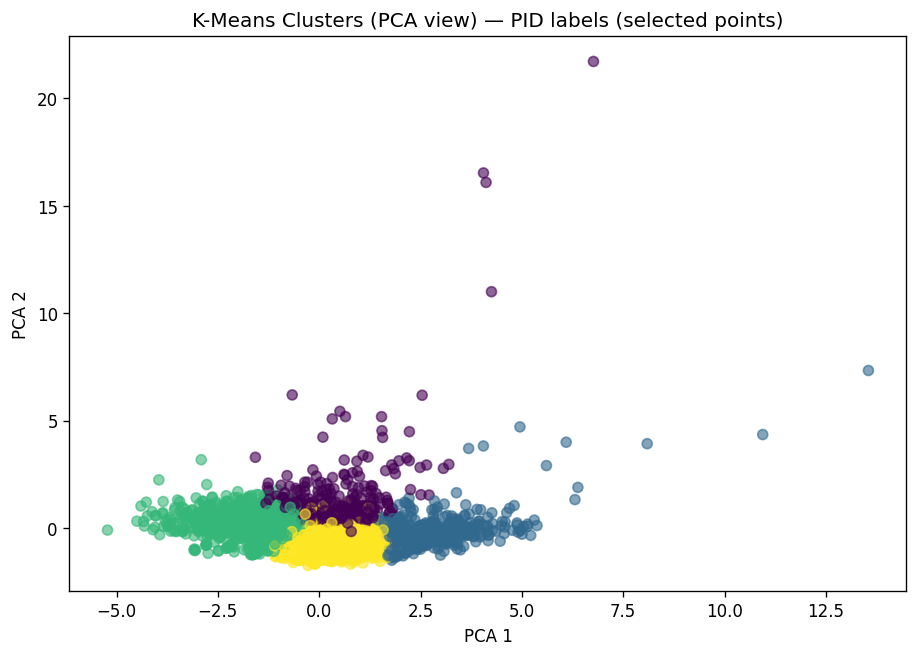

Explained variance by PCA components: [0.503 0.178]


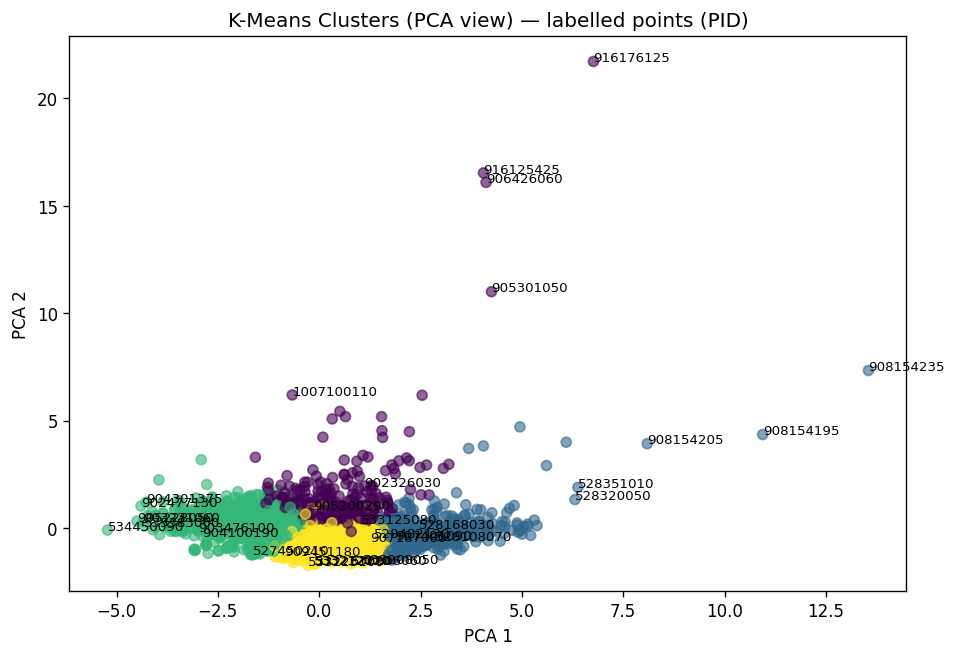

In [ ]:
# Code Cell 7 (UPDATED): PCA plot + PID labels (readable)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create plotting dataframe
plot_df = df_seg.copy()
plot_df["PCA1"] = X_pca[:, 0]
plot_df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(9,6))
plt.scatter(plot_df["PCA1"], plot_df["PCA2"], c=plot_df["Cluster_KMeans"], alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (PCA view) — PID labels (selected points)")
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_.round(3))

# --- Label only selected points (outliers + a few per cluster) ---

# 1) Outliers based on PCA extremes
idx_label = set()
idx_label |= set(plot_df.nlargest(6, "PCA1").index)
idx_label |= set(plot_df.nsmallest(6, "PCA1").index)
idx_label |= set(plot_df.nlargest(6, "PCA2").index)
idx_label |= set(plot_df.nsmallest(6, "PCA2").index)

# 2) Add a few random points per cluster (for readability)
np.random.seed(42)
for c in sorted(plot_df["Cluster_KMeans"].unique()):
    sample_idx = plot_df[plot_df["Cluster_KMeans"] == c].sample(3, random_state=42).index
    idx_label |= set(sample_idx)

# Plot again with labels
plt.figure(figsize=(9,6))
plt.scatter(plot_df["PCA1"], plot_df["PCA2"], c=plot_df["Cluster_KMeans"], alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (PCA view) — labelled points (PID)")

for i in idx_label:
    plt.text(plot_df.loc[i, "PCA1"], plot_df.loc[i, "PCA2"],
             str(plot_df.loc[i, "PID"]), fontsize=8)

plt.show()


In [ ]:
# NEW Code Cell 7B: Plotly hover labels (PID) + dropdown filter

!pip -q install plotly

import plotly.graph_objects as go
import numpy as np

# Build a plotting dataframe (PCA already computed in Cell 7 as X_pca)
plot_df = df_seg.copy()
plot_df["PCA1"] = X_pca[:, 0]
plot_df["PCA2"] = X_pca[:, 1]
plot_df["Cluster"] = plot_df["Cluster_KMeans"].astype(int)

# Columns you want to show on hover
hover_cols = ["PID", "SalePrice", "Gr Liv Area", "Overall Qual",
              "Total Bsmt SF", "Garage Area", "Year Built", "Lot Area"]

clusters = sorted(plot_df["Cluster"].unique())

fig = go.Figure()

# Create one trace per cluster (so dropdown can hide/show traces)
for c in clusters:
    d = plot_df[plot_df["Cluster"] == c]

    # customdata holds values used in hover template
    customdata = d[hover_cols].values

    fig.add_trace(go.Scatter(
        x=d["PCA1"],
        y=d["PCA2"],
        mode="markers",
        name=f"Cluster {c}",
        customdata=customdata,
        marker=dict(size=7, opacity=0.75),
        hovertemplate=(
            "<b>PID:</b> %{customdata[0]}<br>"
            "<b>SalePrice:</b> %{customdata[1]:,.0f}<br><br>"
            "<b>Gr Liv Area:</b> %{customdata[2]:,.0f}<br>"
            "<b>Overall Qual:</b> %{customdata[3]}<br>"
            "<b>Total Bsmt SF:</b> %{customdata[4]:,.0f}<br>"
            "<b>Garage Area:</b> %{customdata[5]:,.0f}<br>"
            "<b>Year Built:</b> %{customdata[6]}<br>"
            "<b>Lot Area:</b> %{customdata[7]:,.0f}<br>"
            "<extra></extra>"
        )
    ))

# Dropdown buttons: All + each cluster
buttons = []

# Show all traces
buttons.append(dict(
    label="All Clusters",
    method="update",
    args=[{"visible": [True]*len(clusters)},
          {"title": "K-Means Clusters (PCA view) — All Clusters"}]
))

# Show one cluster at a time
for i, c in enumerate(clusters):
    visible = [False]*len(clusters)
    visible[i] = True
    buttons.append(dict(
        label=f"Cluster {c}",
        method="update",
        args=[{"visible": visible},
              {"title": f"K-Means Cluster {c} (PCA view) — Hover shows PID"}]
    ))

fig.update_layout(
    title="K-Means Clusters (PCA view) — Hover shows PID + details",
    xaxis_title="PCA 1",
    yaxis_title="PCA 2",
    legend_title="Clusters",
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=1.02,
        y=1.0,
        xanchor="left",
        yanchor="top"
    )],
    margin=dict(r=220)  # space for dropdown on right
)

fig.show()

## 7) Cluster profiling (business deliverable)

In [ ]:
# Code Cell 8: Profiling table
mean_tbl = df_seg.groupby("Cluster_KMeans")[cluster_features + [target_for_evaluation]].mean()
med_tbl  = df_seg.groupby("Cluster_KMeans")[cluster_features + [target_for_evaluation]].median()
sizes = df_seg["Cluster_KMeans"].value_counts().sort_index()

profile = mean_tbl.copy()
profile.insert(0, "ClusterSize", sizes.values)
profile["SalePrice_median"] = med_tbl[target_for_evaluation]
profile.round(2)


,ClusterSize,Gr Liv Area,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Lot Area,SalePrice,SalePrice_median
Cluster_KMeans,,,,,,,,,
0,336,1931.85,5.82,1153.40,547.86,1947.15,17093.28,188287.04,177562.5
1,465,2099.83,8.15,1618.96,752.61,2001.37,12479.21,313002.12,293000.0
2,1136,1156.87,4.97,807.06,307.15,1947.78,8394.29,121676.95,125000.0
3,991,1464.83,6.52,1031.43,506.20,1992.58,8714.75,184124.22,180000.0


### 7A) Cluster centers in original units

In [ ]:
# Code Cell 9: Inverse-transform cluster centers
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=cluster_features)
centers_df.insert(0, "Cluster", range(K_FINAL))
centers_df.round(1)


,Cluster,Gr Liv Area,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Lot Area
0,0,1934.4,5.8,1153.2,547.9,1947.1,17142.5
1,1,2099.8,8.1,1619.0,752.6,2001.4,12479.2
2,2,1156.7,5.0,806.8,306.9,1947.8,8395.2
3,3,1464.8,6.5,1031.8,506.4,1992.5,8713.7


## 8) Statistical validation: do segments differ in SalePrice?

In [ ]:
# Code Cell 10: ANOVA + Kruskal tests on SalePrice
groups = [df_seg.loc[df_seg["Cluster_KMeans"]==c, target_for_evaluation].values for c in range(K_FINAL)]

f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kruskal = stats.kruskal(*groups)

print("ANOVA:   F =", round(f_stat,3), " p =", p_anova)
print("Kruskal: H =", round(h_stat,3), " p =", p_kruskal)


ANOVA:   F = 1803.666  p = 0.0
Kruskal: H = 2014.877  p = 0.0


## 9) Hierarchical clustering + dendrogram (sampled for readability)

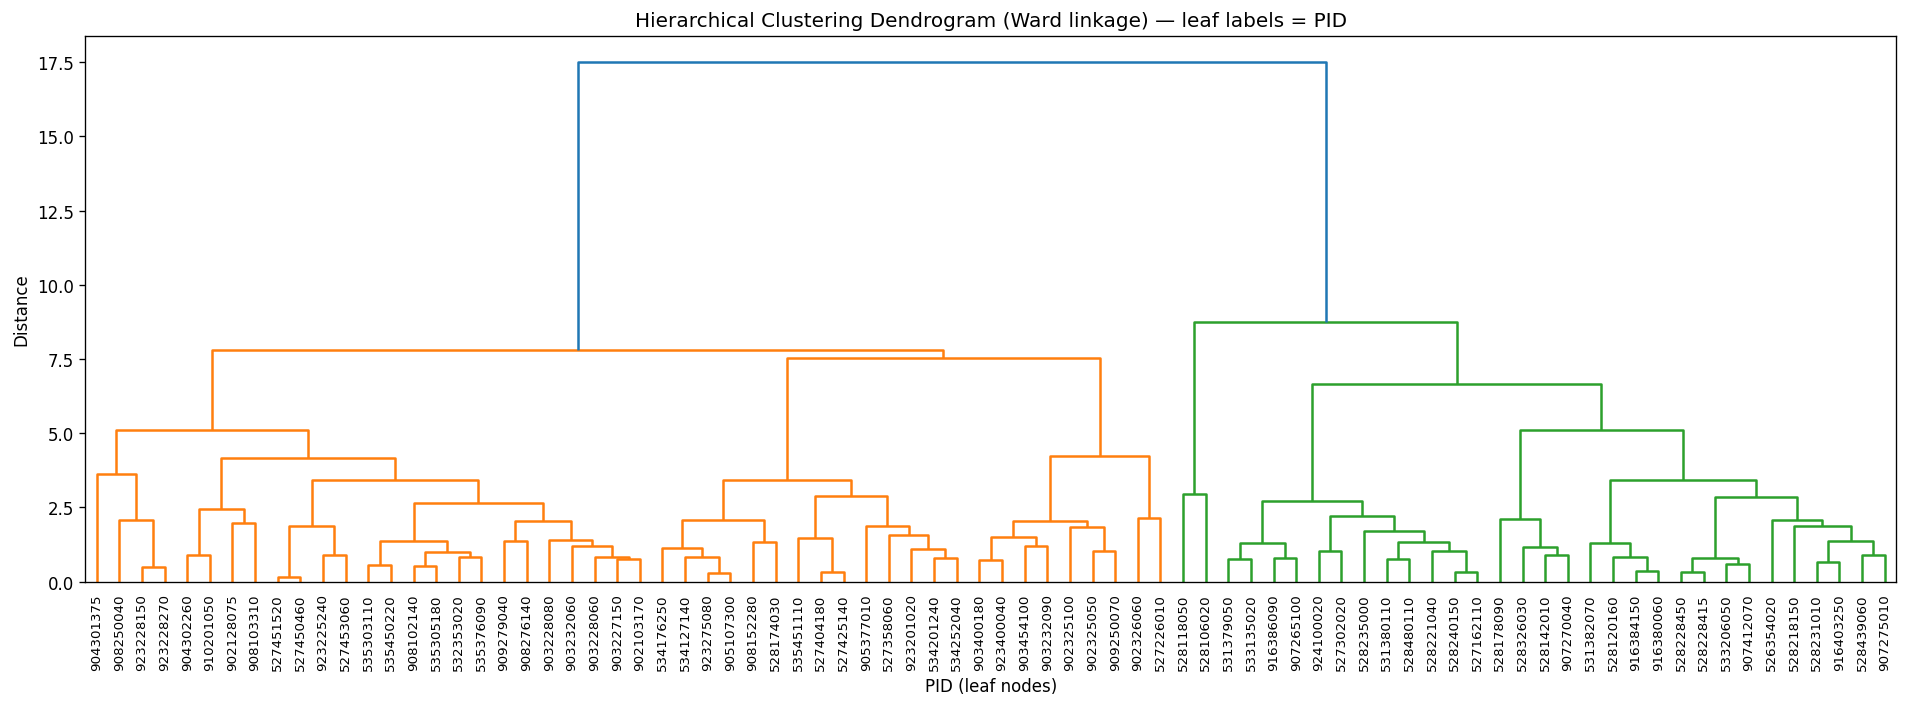

In [ ]:

# Code Cell 11 (UPDATED): Dendrogram with PID labels on leaf nodes

# Use a smaller sample so leaf labels are readable
sample_n = 80   # try 60–120
df_sample = df_seg.sample(sample_n, random_state=42).copy()

# Leaf labels = PID
leaf_labels = df_sample["PID"].astype(str).tolist()

# Standardize using the SAME scaler
X_sample = scaler.transform(df_sample[cluster_features].values)

# Ward linkage
Z = linkage(X_sample, method="ward")

# Plot dendrogram with leaf labels
plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=leaf_labels,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage) — leaf labels = PID")
plt.xlabel("PID (leaf nodes)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Fit Agglomerative clustering (same K_FINAL for comparison)

In [ ]:
# Code Cell 12: Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
df_seg["Cluster_Hier"] = agg.fit_predict(X_scaled)

df_seg["Cluster_Hier"].value_counts().sort_index()


,count
Cluster_Hier,
0,1524
1,1035
2,365
3,4


## 10) Profile hierarchical clusters

In [ ]:
# Code Cell 13: Hierarchical profiling
mean_h = df_seg.groupby("Cluster_Hier")[cluster_features + [target_for_evaluation]].mean()
med_h  = df_seg.groupby("Cluster_Hier")[target_for_evaluation].median()
sizes_h = df_seg["Cluster_Hier"].value_counts().sort_index()

profile_h = mean_h.copy()
profile_h.insert(0, "ClusterSize", sizes_h.values)
profile_h["SalePrice_median"] = med_h
profile_h.round(2)


,ClusterSize,Gr Liv Area,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Lot Area,SalePrice,SalePrice_median
Cluster_Hier,,,,,,,,,
0,1524,1500.09,6.26,1099.56,528.27,1982.60,10314.77,184022.44,178000.0
1,1035,1256.80,5.10,790.15,274.65,1945.02,8447.89,124915.59,125500.0
2,365,2182.63,8.22,1586.44,803.01,1999.38,12605.70,324881.55,309000.0
3,4,1947.50,6.25,1680.50,542.50,1964.75,163513.50,295737.50,289500.0


## 11) Name segments (persona labels)

In [ ]:
# Code Cell 14: Cluster naming (edit after profiling)
cluster_names = {c: f"Segment {c}: (rename after profiling)" for c in range(K_FINAL)}
df_seg["ClusterName_KMeans"] = df_seg["Cluster_KMeans"].map(cluster_names)
df_seg[["Cluster_KMeans","ClusterName_KMeans"]].drop_duplicates().sort_values("Cluster_KMeans")


,Cluster_KMeans,ClusterName_KMeans
0,0,Segment 0: (rename after profiling)
3,1,Segment 1: (rename after profiling)
1,2,Segment 2: (rename after profiling)
4,3,Segment 3: (rename after profiling)


## 12) Visual: SalePrice distribution by segment

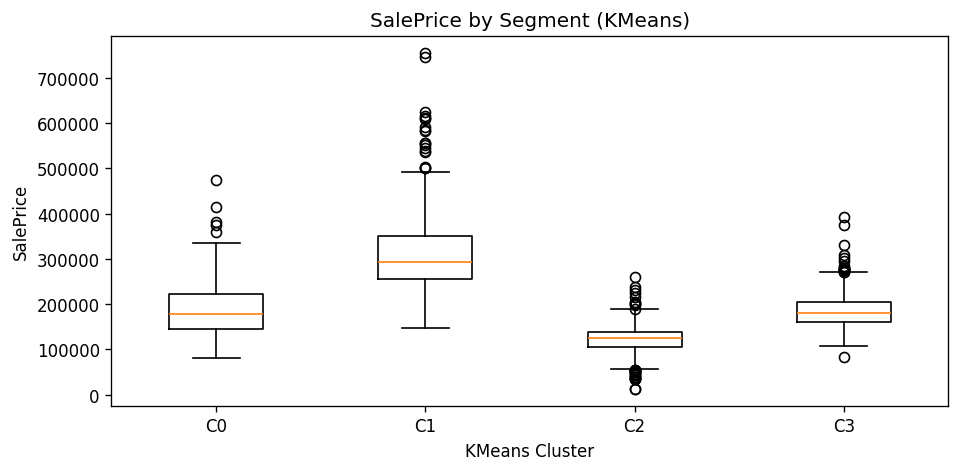

In [ ]:
# Code Cell 15: Boxplot of SalePrice by cluster
plt.figure(figsize=(9,4))
plt.boxplot([df_seg.loc[df_seg["Cluster_KMeans"]==c, target_for_evaluation] for c in range(K_FINAL)],
            labels=[f"C{c}" for c in range(K_FINAL)])
plt.xlabel("KMeans Cluster")
plt.ylabel("SalePrice")
plt.title("SalePrice by Segment (KMeans)")
plt.show()


# End-of-session takeaways
- Segmentation groups similar houses using selected features.
- Scaling is mandatory for distance-based methods.
- Choose k using elbow + silhouette + business logic.
- Profile clusters and validate differences statistically.
